# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [1]:
# Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr
from scipy.stats import chi2_contingency


### Cargar Dataset

In [2]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [3]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

💡
Después de analizar la información anterior, completa la siguiente sección.  
- Si aplica, señala la o las columnas que requieren algun cambio

Recuerda eliminar este bloque de texto antes de subir el proyecto a tu portafolio.


#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- 'nivel_ingreso'
- 'visitas_mes'
- 'compras_mes'
- 'gasto_publicidad_dirigida'
- 'satisfaccion'
- 'miembro_premium'
- 'abandono'
- 'ingreso_anual'

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna 'edad' está como float64, debería ser int64 .


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [4]:
# Corregir el tipo de dato
df['edad'] = df['edad'].astype('int')

In [5]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [6]:
# Estadísticas descriptivas de variables numéricas
variables_numericas = ['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes', 'gasto_publicidad_dirigida', 'satisfaccion', 'ingreso_anual']
df[variables_numericas].describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,244.690000



Diagnóstico inicial de variables numéricas

- `edad` — No parece haber outliers extremos. Perfil típico: adulgo joven-maduro. Distribución bastante simétrica. 
- 'nivel_ingreso' — Media y mediana bastante similares. Desviación estándar relativamente alta. Podría requerir segmentación.
-  'visitas_mes' — Media y mediana bastante similares. Máximo 25, posible usuario muy activo.
-  'compras_mes' —  Media y mediana similares. 25% no compra nada. Máximo alejado de la media y mediana. Posible comprador grande.
-  'gasto_publicidad_dirigida' — Presenta mucha variabilidad. Mediana y media similares. Hay clientes sin inversión publicitaria.
-  'satisfaccion' — Media y mediana similares. Del rango 1 a 5, la satisfacción está en promedio 3.6. Poca dispersión
-  'ingreso_anual' — 25% no representa ingreso. Posibles outliers, con distribución hacia la derecha. Revisar con boxplot.

#### Explorar variables binarias

In [7]:
# Verificar que cada columna tenga únicamente dos valores posibles
variables_binarias = ['miembro_premium', 'abandono']
df[variables_binarias].describe()

,miembro_premium,abandono
count,15000.000000,15000.000000
mean,0.139267,0.150733
std,0.346236,0.357801
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,1.000000,1.000000



Diagnóstico inicial de variables binarias
- 'miembro_premium' — Variable binaria. Desbalanceada, con pocos clientes premium. Poner antención.
-  'abandono' — Variable binaria. Abandono bajo, con churn del 15%. Necesitaría revisar más a profunidad.

#### Explorar variables categóricas

In [8]:
# Verificar el número de valores únicos por variable categórica
# print(df['id_cliente'].value_counts()) Es el consecutivo del id de clientes
print("Frecuencia absoluta por tipo de dispositivo: ")
print(df['tipo_dispositivo'].value_counts())
print("Frecuencia relativa por tipo de dispositivo: ")
print(df['tipo_dispositivo'].value_counts(normalize=True))
print("Frecuencia absoluta por región: ")
print(df['region'].value_counts())
print("Frecuencia relativa por región: ")
print(df['region'].value_counts(normalize=True))

Frecuencia absoluta por tipo de dispositivo: 
móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64
Frecuencia relativa por tipo de dispositivo: 
móvil         0.654533
escritorio    0.248000
tablet        0.097467
Name: tipo_dispositivo, dtype: float64
Frecuencia absoluta por región: 
norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64
Frecuencia relativa por región: 
norte    0.2930
oeste    0.2540
sur      0.2484
este     0.2046
Name: region, dtype: float64


In [9]:
# Explorar variables categóricas y cómo se distribuyen
print("Resumen categórico tipo de dispositivo: ")
print(df['tipo_dispositivo'].describe())
print("Resumen categórico región: ")
print(df['region'].describe())

Resumen categórico tipo de dispositivo: 
count     15000
unique        3
top       móvil
freq       9818
Name: tipo_dispositivo, dtype: object
Resumen categórico región: 
count     15000
unique        4
top       norte
freq       4395
Name: region, dtype: object



Diagnóstico inicial de variables categóricas

- `tipo_dispositivo` — Hay 3 tipos de dispositivos: móvil, escritorio y tablet. El dipositivo móvil es el más frecuente y representa el 65.45%. Escritorio representa el 24.80% y tablet el 9.74%. El móvil parece ser central para el negocio.
- 'region' : Hay 4 regiones: norte, oeste, sur y este. Norte es la región más frecuente y representa el 29.30%, mientra que oeste tiene el 25.40%, sur el 24.84% y este el 20.46%. La región sur parece estar rezagada en relación con las demás.  

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

Text(0.5, 1.0, 'Correlation Heatmap - NovaRetail+')

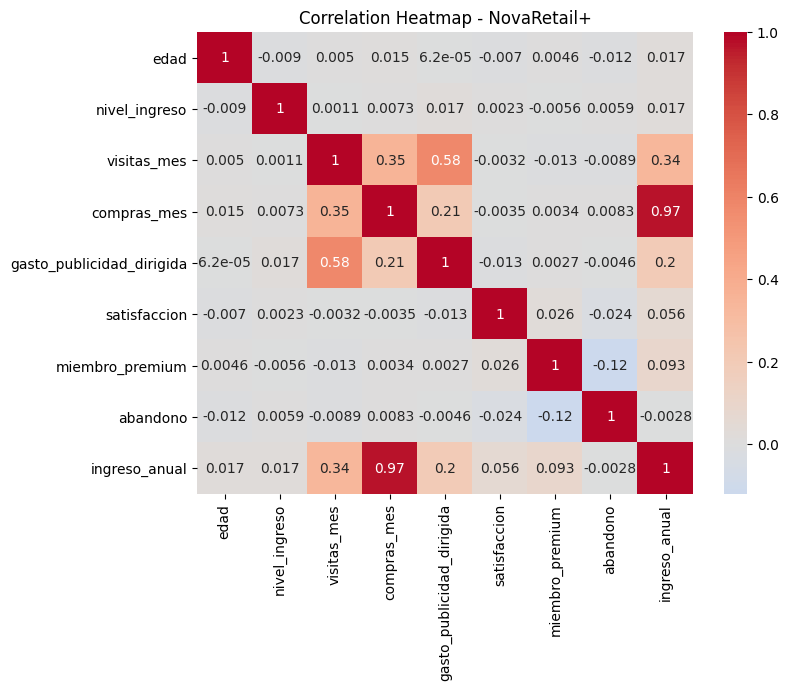

In [10]:
# Visualizar la matriz de correlación para identificar relaciones
corr = df.corr() # Matriz de la correlación
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - NovaRetail+")


Observaciones generales (Heatmap)  
- Se observa una correlación lineal fuerte (0.58) entre 'visitas_mes' y 'gasto_publicidad_dirigida'. 'copras_mes' aparece con una correlación altísima (0.97), muy probablemente se trata de una duplicación de información, bajo otro rubro, es decir, es una variable redundante, que se podría dejar de considerar. 


Observaciones respecto a `ingreso_anual`  
- Presenta en general baja correlación lineal con las demás variables. 'visitas_mes' (0.34) y 'gasto_pubilicidad_dirigida' (0.20) Son las que en este punto presentan mayor correlación. Son también, como se vio en el punto anterior, las que mayor correlación tienen entre sí. 


### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
  - Genera el gráfico.
  - Describe brevemente qué patrones o tendencias observas.

- **Si decides no incluirlo**:
  - Explica por qué.

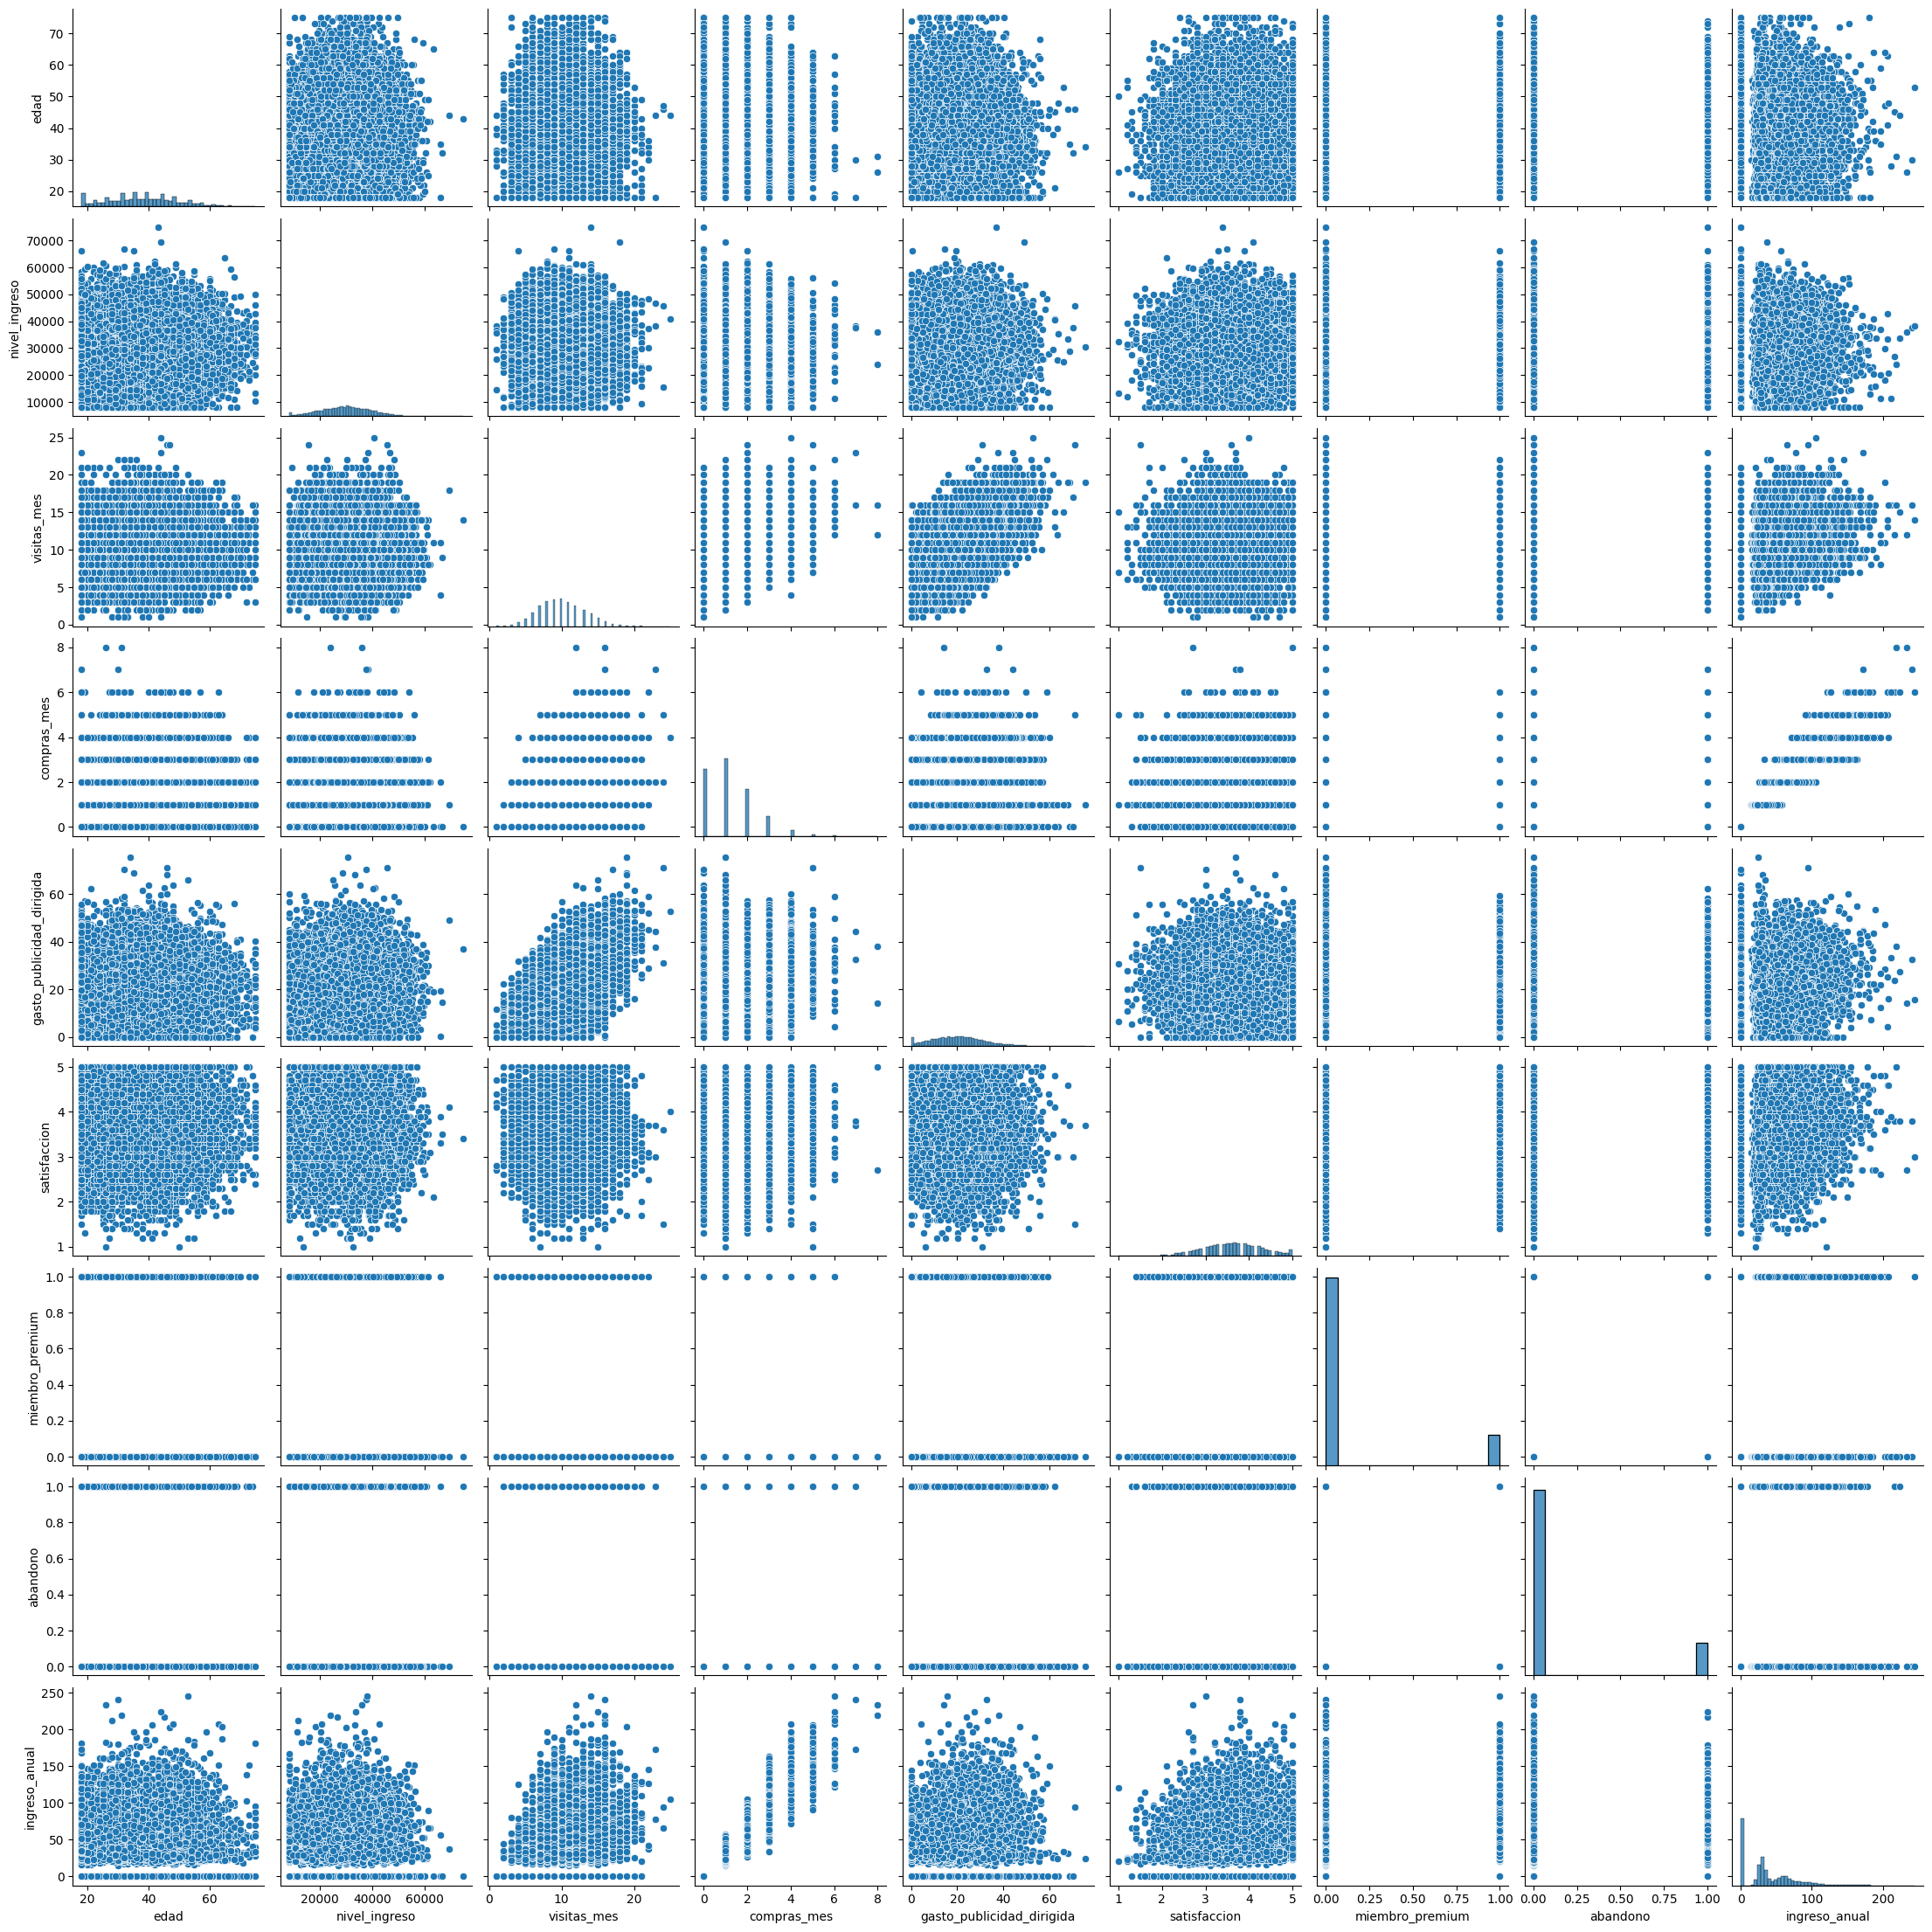

In [11]:
sns.pairplot(df)

### Scatterplot para pares clave

<AxesSubplot:xlabel='visitas_mes', ylabel='gasto_publicidad_dirigida'>

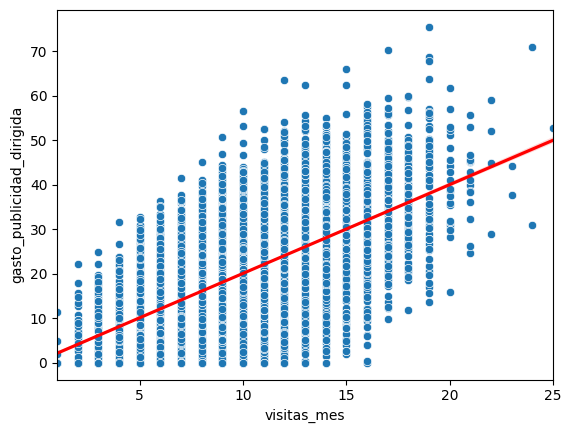

In [12]:

# Visualizar pares de variables con relaciones moderadas o fuertes
# Se revisar el par de variables con la correlación más fuerte: 'visitas_mes' y 'gasto_publicidad_dirigida'
sns.scatterplot(data=df, x="visitas_mes", y="gasto_publicidad_dirigida")
# Con línea de tendencia
sns.regplot(data=df, x="visitas_mes", y="gasto_publicidad_dirigida", scatter=False, color='red')


<AxesSubplot:xlabel='ingreso_anual', ylabel='visitas_mes'>

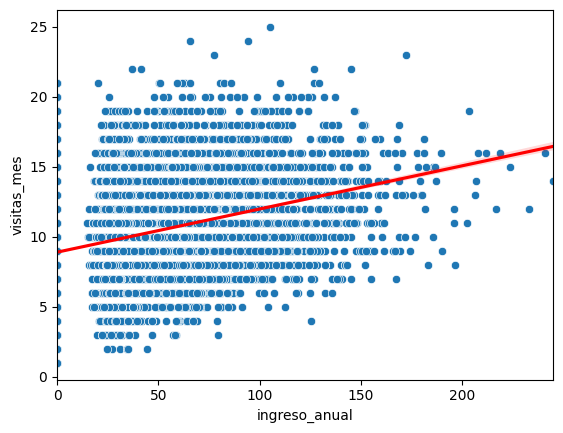

In [13]:
# Se revisa el par de variables con la variable principal y aquella con la que tiene mayor correlación más fuerte: 'ingreso_anual' y 'visitas_mes'
sns.scatterplot(data=df, x="ingreso_anual", y="visitas_mes")
# Con línea de tendencia
sns.regplot(data=df, x="ingreso_anual", y="visitas_mes", scatter=False, color='red')



Observaciones iniciales (Scatterplot): Se confirma visualmente la colinealidad entre 'ingreso_anual' y 'compras_mes'.
Se observa una tendencia positiva clara entre visitas mes e 'ingreso_anual' (y 'compras_mes'), lo que sugiere que a un mayor número de visitas, más compras, aunque no todas las visitas concreten compras. Se podría calcular la tasa de conversión. 
Se confirma también la corelación entre 'visitas_mes' y 'gasto_publicidad_dirigida'.
En general, la variable de 'ingreso_anual' tiene cola hacia la derecha, lo que sugiere un máximo alto (coincide con los números vistos más arriba). 
Las variables binarias se podrían quitar. 

**'visitas_mes' vs 'gasto_publicidad_dirigido'**
- Dirección hacia la derecha: existe una relación positiva moderada, a mayor gasto en publicidad dirigida, mayor número de visitas.
- Hay dispersión amplia, lo que muestra que la publicidad no explica todo el comportamiento y hay un probable techo después del cual no hay diferencia. 
- 

**'ingreso_anual' vs 'visitas_mes'**
- Tiene una tendencia positiva, de pendiente moderada y relación aproximadamente lineal, que coincide con el 0.34 visto en el heatmap. 
- Naturalmente, el ingreso anual no tiene una correlación muy fuerte con las visitas mensuales. Se podría determinar una tasa de conversión del ingreso promedio por visita.
- Tienen mayor concentración en ventas bajas y medias. 

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [14]:
# Calcular correlación entre variables relevantes

corr_pearson1 = df[['visitas_mes', 'gasto_publicidad_dirigida']].corr(method ='pearson')
corr_spearman1 = df[['visitas_mes', 'gasto_publicidad_dirigida']].corr(method ='spearman')

print(f'Correlación Pearson:\n{corr_pearson1}')
print(f'Correlación Spearman:\n{corr_spearman1}')


Correlación Pearson:
                           visitas_mes  gasto_publicidad_dirigida
visitas_mes                   1.000000                   0.578947
gasto_publicidad_dirigida     0.578947                   1.000000
Correlación Spearman:
                           visitas_mes  gasto_publicidad_dirigida
visitas_mes                   1.000000                   0.559267
gasto_publicidad_dirigida     0.559267                   1.000000


In [15]:
# Calcular correlación entre variables relevantes
corr_pearson2 = df[['ingreso_anual','visitas_mes' ]].corr(method = 'pearson')
corr_spearman2 = df[['ingreso_anual', 'visitas_mes']].corr(method = 'spearman')

print('correlación Pearson: ', corr_pearson2)
print('Correlación Spearman: ', corr_spearman2)

correlación Pearson:                 ingreso_anual  visitas_mes
ingreso_anual       1.000000     0.337147
visitas_mes         0.337147     1.000000
Correlación Spearman:                 ingreso_anual  visitas_mes
ingreso_anual       1.000000     0.320954
visitas_mes         0.320954     1.000000


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves: dirección, magnitud y posible colinealidad.


Observaciones de correlación

** 'gasto_publicidad_dirigida' vs 'visitas_mes'**
- Correlación positiva fuerte, sin outlieres extremos que distorsionen. Ambos coeficientes son muy similares, lo que sugiere estabilidad en los datos. 
- Sugiere que a mayor gasto publicitario, hay más visitas al mes. 

** ingreso_anual vs visitas_mes**
- Correlación aproximadamente lineal, positiva moderada, sin outliers exremos que la distorsionen. La relación lineal es débil.
- Sugiere que a mayores visitas mensuales, mayores ventas, pero no de manera determinante. 

### Punto-biserial

In [16]:
# Calcular correlación entre variables relevantes
# Codificar a 0 y 1 
# df['miembro_premium'] = df['miembro_premium'].replace({"Yes": 1, "No": 0}) No es necesario, ya estaban en formato de 0 y 1


pb1 = pointbiserialr(df['ingreso_anual'], df['miembro_premium'])

pb2 = pointbiserialr(df['ingreso_anual'], df['abandono'])

print('Correlación Ingreso anual y miebros premium:', pb1)
print('Correlación Ingreso anual y abandono:', pb2)


Correlación Ingreso anual y miebros premium: SignificanceResult(statistic=0.0930994396198015, pvalue=3.0943076155242597e-30)
Correlación Ingreso anual y abandono: SignificanceResult(statistic=-0.002823934021617148, pvalue=0.7294691719078393)



Observaciones Punto-biserial

** 'ingreso_anual' vs 'miembro_premium'**
- Relación presenta dirección positiva, es decir, los miembros premium presentan una ligera mayor proporción de representar un ingreso anual superior. La magnitud (0.093) es muy baja. En términos prácticos, el ingreso anual parece no depender de miembros premium y no premium. 

** 'ingreso_anual' vs 'abandono'**
- Relación presenta una dirección negativa, aunque casi nula, pues presenta una magnitud prácticamente de cero (0.0028). Se podría decir que no hay una relación real en términos de magnitud.
- Parecería que el intgreso mensual no depende mucho del tipo de miembro, ni de si abandonan o no.

### V de Cramér

In [17]:
# Función para calcular V de Cramér
# Crear tabla de contingencia:
tabla = pd.crosstab(df['tipo_dispositivo'], df['region'])
print('tabla:', tabla)
chi2, p, dof, expected = chi2_contingency(tabla)
print("Chi2:", chi2)

tabla: region            este  norte  oeste   sur
tipo_dispositivo                          
escritorio         766   1125    935   894
móvil             2003   2843   2489  2483
tablet             300    427    386   349
Chi2: 4.596697852095489


In [18]:
# Aplicar V de Cramér en variables relevantes
# Conteos de la tabla
n = tabla.sum().sum()

# Se usa el valor de chi-cuadrado
cramers_v = np.sqrt(chi2 / (n * (min(tabla.shape)-1)))
cramers_v



0.012378338407739397

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.
Observaciones V de Cramér: En este caso, la asociación entre las variables categóricas 'tipo_dispositivo' y 'region', es muy débil. No parece haber un patrón claro entre estas categorías.



<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br>

Las coeficientes de correlación y asociación de la sección 4 fueron correctamente aplicados, bien hecho!
</div>

## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio

---

✍️ **Hallazgos**: Completa los siguientes bloques.   
Si lo crees necesario, puedes agregar mas hallazgos.  

Recuerda eliminar este bloque de texto antes de incluir el proyecto en tu portafolio.

### Hallazgo 1 — 'visitas_mes'y 'gasto_publicidad_dirigida'



**Evidencia visual:** Scatterplot y heatmap   
**Evidencia numérica:** Pearson: 0.578947 / Spearman: 0.559267 

**Interpretación**  
Sin sugerir causalidad, a mayor publicidad dirigida, se registran más visitas al mes. La cercanía entre los coeficientes de Pearson y Spearman sugiere estabilidad en los datos.  


**No podemos afirmar**  
No se puede afirmar que la publicidad esté aumentando las visitas, pues la correlación también podría derivar en que ésta se enfoca más en usuarios que ya son activos, o si hay alguna tercera variable que influya; podría revisarse mediante una prueba de Paradoja de Simpson. Por otra parte, que aumenten las visitas, no significa que aumentan las compras, o se mejore la rentabilidad. 
De ahí que no se pueda afirmar que el efecto sea uniforme. Se podrían hacer pruebas por segmentos. 

**Implicación de negocio**  
Los datos sugieren que la publicidad está relacionada con un mayor tráfico. Dado que el margen es de (0.58), hay margen para la optimización la asignación del presupuesto publicitario: por segmentos, identificar puntos óptimos. Se recomienda un análsis segmentado o temporal para tener más definido el efecto y, como se dijo, aplicar algunas pruebas de Paradoja de Simpson, para aplicar la publicidad de forma más estratégica.


### Hallazgo 2 — 'ingreso_anual' - 'ventas_mes'

**Evidencia visual:** Scatterplot y heatmap
**Evidencia numérica:** Pearson: 0.337147 / Spearman_ 0.320954

**Interpretación**  A mayor número de visitas mensuales, tiende a aumentar el ingreso anual, pero la relación es débil.La correlación lineal es positiva, de magnitud débil-moderada. Relación estable y aproximadamente lineal.  


**No podemos afirmar**  
Que el monto de ventas anuales esté fuertemente vinculado al número de visitas mensuales. Las visitas sólo explican una pequeña parte de la variablidad del ingreso. Otras variables como frecuencia y promedio de la compra, o el tipo de cliente podrían desempeñar un papel más crucial, pero es necesaria una verificación segmentada y verificar Paradoja de Simpson. 

**Implicación de negocio**  
Dado de la correlación es débil, incrementar las visitasno asegura un incremento proporcional de los ingresos. Se sugiere analizar métricas de conversión como premium vs no premium, nivel de ingreso, gasto publicitario. Aunado al hallazgo anterior, la publicidad muestra una asociación más fuerte con el número de visitas que la relación observada entre visitas e ingreso anual. Esto sugiere que el incremento en tráfico no se traduce proporcionalmente en mayores ingresos, lo que podría indicar oportunidades de mejora en la eficiencia de conversión o en la monetización por visita.

<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br>

Las observaciones que haces me parecen bien explicadas, además estan en un formato correcto
</div>

## Sección 6 - Limitaciones y próximos pasos

✍️ **Comentario**: Completa el siguiente bloque.   
Modifica según creas necesario.  

Recuerda eliminar este bloque de texto antes de incluir el proyecto en tu portafolio.


### **Limitaciones**
- El análisis es correlacional, no causal.
- Posibles efectos de segmentación no explorados. El heatmap muestra, en general, bajos niveles de correlación.
- Falta dimensión temporal.
- La asignación de publicidad podría no ser aleatoria, sino dirigida estratégicamente a ciertos segmentos, lo que ya podría estar influyendo en las correlaciones observadas.
- Se señala la multicolinealidad potencial entre 'ingreso_anual' y 'compras_mes'

### **Próximos pasos** 

Probar segmentación adicional:
Conductual
- Frecuencia de compras
- Tasa de conversión (compras/visitas)
- Promedio de compra
  
Estructural
- Tipo de cliente
- Región
- Dispositivo

Revisar Paradoja de Simpson
- Evaluar si las relaciones observadas a nivel agregado se mantienen dentro de segmentos específicos. 

Revisar coeficientes de conversión
Analizar la eficiencia del embudo:
Visitas --> Compras
Compras --> Ingreso
Publicidad --> Ingreso

La publicidad muestra una asociación clara con el aumento de visitas, pero este incremento no se traduce proporcionalmente en ingresos. El desafío estratégico parece ubicarse en la conversión y monetización del tráfico generado. Se recomienda profundizar el análisis por segmentos y evaluar la eficiencia del embudo completo antes de ajustar la inversión publicitaria.


In [19]:
# Generar archivo CSV del dataset procesado
df.to_csv('novaretail_analysis.csv', index=False)
print("Archivo CSV generado exitosamente: novaretail_analysis.csv")

Archivo CSV generado exitosamente: novaretail_analysis.csv


# Comentario general del revisor
<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Has realizado un buen trabajo, me doy cuenta de que has aplicado los conocimientos que has adquirido durante el curso, los procedimientos realizados son correctos, este es un ejercicio que nos ayuda a entender y comprobar que la correlación no siempre indica causalidad.<br/>    
<br/>    
Te felicito por el buen trabajo que has hecho, continúa así y mucho éxito en el siguiente Sprint!
</div>


<div class="alert alert-block alert-success">
<b>Aspectos positivos del proyecto</b> <a class="tocSkip"></a><br />

- Las observaciones intermedias, así como las conclusiones finales me parecen bastante detalladas
- El proyecto esta ordenado
- El proyecto es directo y conciso
    
</div> 
